In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score


# This is the file you are reading
file_path = 'output_Pune_builderfloor.csv'

In [5]:
df = pd.read_csv(file_path)
print("--- Initial Data Info ---")
df.info()
df.head()

--- Initial Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   location               123 non-null    object 
 1   area                   123 non-null    int64  
 2   price                  123 non-null    int64  
 3   price_currency         123 non-null    object 
 4   status                 41 non-null     float64
 5   new/resale             123 non-null    int64  
 6   price_negotiable       123 non-null    int64  
 7   description            118 non-null    object 
 8   security_deposit       123 non-null    int64  
 9   facing                 76 non-null     object 
 10  furnished              123 non-null    int64  
 11  age of property        123 non-null    int64  
 12  Lift(s)                123 non-null    int64  
 13  Full Power Backup      123 non-null    int64  
 14  24 X 7 Security        123 non-n

,location,area,price,price_currency,status,new/resale,price_negotiable,description,security_deposit,facing,...,Indoor Games,Multipurpose Room,Staff Quarter,Cafeteria,School,Maintenance Staff,Shopping Mall,Golf Course,ATM,Hospital
0,Warje,832,6500000,INR,0.0,0,0,A spacious 2 bhk builder floor is available fo...,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Hinjawadi Village,800,6000000,INR,NaN,0,0,A 2 bhk property is available for sale in Hinj...,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Wagholi,849,3399396,INR,1.0,0,0,Well designed 2 bhk builder floor is available...,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Karve Nagar,1550,20498750,INR,NaN,0,0,A spacious 3 bhk builder floor is available fo...,1,north,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Kharadi,850,6400000,INR,1.0,0,0,It has a built-up area of 850 sqft and is pric...,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### droping col with > 70 % null

In [6]:
missing_percentage = df.isnull().mean()
cols_to_drop_auto = missing_percentage[missing_percentage > 0.7].index

print(f"\n--- Dropping {len(cols_to_drop_auto)} columns with >70% nulls ---")
print(list(cols_to_drop_auto))


--- Dropping 12 columns with >70% nulls ---
['project_score', 'Vaastu Compliant', 'Indoor Games', 'Multipurpose Room', 'Staff Quarter', 'Cafeteria', 'School', 'Maintenance Staff', 'Shopping Mall', 'Golf Course', 'ATM', 'Hospital']


In [7]:
cols_to_drop_manual = [
    'description',       # Unstructured text
    'price_currency',    # Only one value (INR)
    'status'             # Too many nulls and complex
]

# Combine the lists and drop them all
all_cols_to_drop = cols_to_drop_auto.union(cols_to_drop_manual)
df_cleaned = df.drop(columns=all_cols_to_drop)

print(f"\n--- Data shape after dropping: {df_cleaned.shape} ---")
print("Remaining columns:")
print(list(df_cleaned.columns))


--- Data shape after dropping: (123, 24) ---
Remaining columns:
['location', 'area', 'price', 'new/resale', 'price_negotiable', 'security_deposit', 'facing', 'furnished', 'age of property', 'Lift(s)', 'Full Power Backup', '24 X 7 Security', "Children's play area", 'Club House', 'Gymnasium', 'Swimming Pool', 'Sports Facility', 'Jogging Track', 'Landscaped Gardens', 'locality_score', 'builder_experience', 'Rain Water Harvesting', 'Intercom', 'Car Parking']


In [8]:
df_cleaned['facing'] = df_cleaned['facing'].fillna('Unknown')
print("\nFilled 'facing' nulls with 'Unknown'.")


Filled 'facing' nulls with 'Unknown'.


In [9]:
num_cols_with_na = ['locality_score', 'builder_experience']

for col in num_cols_with_na:
    if col in df_cleaned.columns:
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)
        print(f"Filled '{col}' nulls with median value: {median_val}")

Filled 'locality_score' nulls with median value: 8.8
Filled 'builder_experience' nulls with median value: 89.5


In [10]:
remaining_na_cols = df_cleaned.columns[df_cleaned.isnull().any()]
print(f"\n--- Filling remaining amenity nulls with 0 ---")
print(list(remaining_na_cols))

df_cleaned = df_cleaned.fillna(0)


--- Filling remaining amenity nulls with 0 ---
['Rain Water Harvesting', 'Intercom', 'Car Parking']


In [11]:
print(f"\nTotal nulls remaining: {df_cleaned.isnull().sum().sum()}")


Total nulls remaining: 0


### creating USPs and calculating key values

In [12]:
df_cleaned['price_per_sqft'] = df_cleaned['price'] / df_cleaned['area']
print("\nCreated 'price_per_sqft' feature.")


Created 'price_per_sqft' feature.


In [13]:
# List of all possible amenity columns from the original file
amenity_cols = [
    'Lift(s)', 'Full Power Backup', '24 X 7 Security', "Children's play area",
    'Club House', 'Gymnasium', 'Swimming Pool', 'Sports Facility', 'Jogging Track',
    'Landscaped Gardens', 'Rain Water Harvesting', 'Intercom', 'Car Parking'
]

# Filter list to only columns that *actually* exist in our cleaned frame
amenity_cols_present = [col for col in amenity_cols if col in df_cleaned.columns]

df_cleaned['amenities_score'] = df_cleaned[amenity_cols_present].sum(axis=1)
print("Created 'amenities_score' feature.")

Created 'amenities_score' feature.


In [14]:
df_processed = pd.get_dummies(df_cleaned, columns=['location', 'facing'], drop_first=True)

print(f"\n--- Data shape after encoding: {df_processed.shape} ---")
print("Ready for modeling.")


--- Data shape after encoding: (123, 78) ---
Ready for modeling.


In [15]:
deliverable_file = 'processed_data.csv'
df_processed.to_csv(deliverable_file, index=False)

print(f"Cleaned data saved to: {deliverable_file}")


Cleaned data saved to: processed_data.csv


In [16]:
df2 = pd.read_csv('processed_data.csv')
df2.head()
df2.info()
df2.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 78 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   area                              123 non-null    int64  
 1   price                             123 non-null    int64  
 2   new/resale                        123 non-null    int64  
 3   price_negotiable                  123 non-null    int64  
 4   security_deposit                  123 non-null    int64  
 5   furnished                         123 non-null    int64  
 6   age of property                   123 non-null    int64  
 7   Lift(s)                           123 non-null    int64  
 8   Full Power Backup                 123 non-null    int64  
 9   24 X 7 Security                   123 non-null    int64  
 10  Children's play area              123 non-null    int64  
 11  Club House                        123 non-null    int64  
 12  Gymnasiu

(123, 78)

--- Generating Correlation Heatmap from 'output_Pune_builderfloor.csv' ---


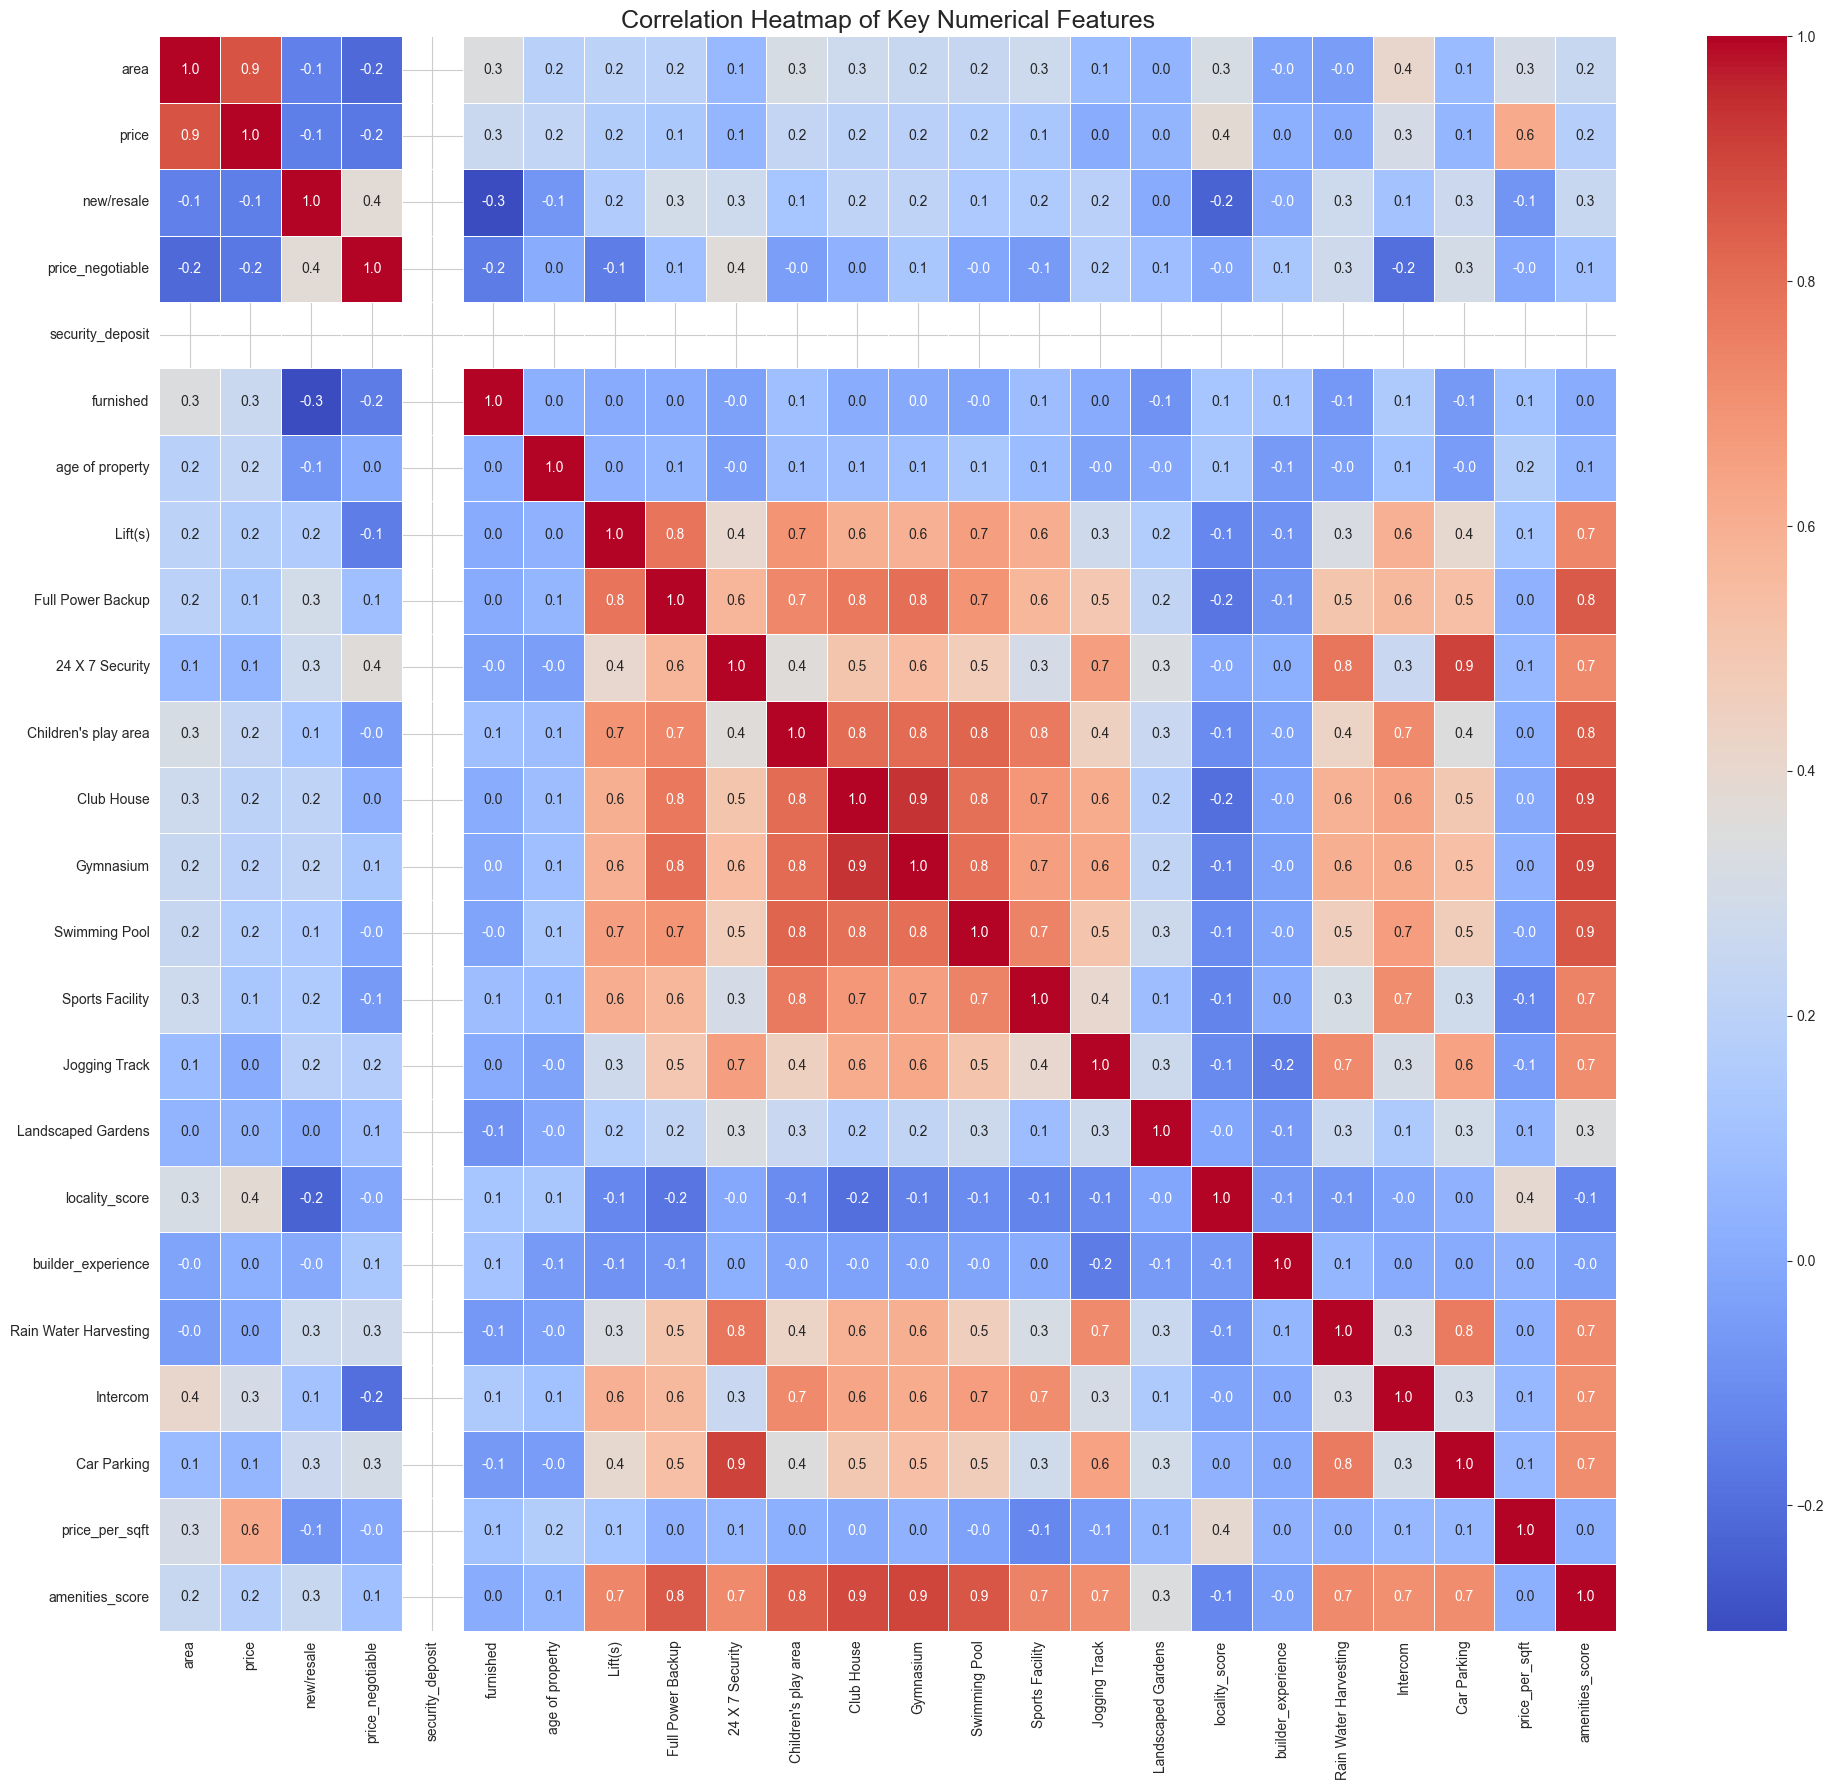

In [17]:
sns.set_style("whitegrid")

file_path = 'output_Pune_builderfloor.csv'

print(f"--- Generating Correlation Heatmap from '{file_path}' ---")

try:
    df = pd.read_csv(file_path)

    
    missing_percentage = df.isnull().mean()
    cols_to_drop_auto = missing_percentage[missing_percentage > 0.7].index
    cols_to_drop_manual = ['description', 'price_currency', 'status']
    all_cols_to_drop = cols_to_drop_auto.union(cols_to_drop_manual)
    df_cleaned = df.drop(columns=all_cols_to_drop, errors='ignore')

    if 'facing' in df_cleaned.columns:
        df_cleaned['facing'] = df_cleaned['facing'].fillna('Unknown')
    
    num_cols_with_na = ['locality_score', 'builder_experience']
    for col in num_cols_with_na:
        if col in df_cleaned.columns:
            median_val = df_cleaned[col].median()
            df_cleaned[col] = df_cleaned[col].fillna(median_val)
            
    df_cleaned = df_cleaned.fillna(0) 

    df_cleaned['price_per_sqft'] = df_cleaned['price'] / df_cleaned['area']
    amenity_cols = [
        'Lift(s)', 'Full Power Backup', '24 X 7 Security', "Children's play area",
        'Club House', 'Gymnasium', 'Swimming Pool', 'Sports Facility', 'Jogging Track',
        'Landscaped Gardens', 'Rain Water Harvesting', 'Intercom', 'Car Parking'
    ]
    amenity_cols_present = [col for col in amenity_cols if col in df_cleaned.columns]
    df_cleaned['amenities_score'] = df_cleaned[amenity_cols_present].sum(axis=1)

    numeric_df = df_cleaned.select_dtypes(include=[np.number])

    corr_matrix = numeric_df.corr()

    # Plot the heatmap
    plt.figure(figsize=(20, 18))
    sns.heatmap(
        corr_matrix, 
        annot=True,          
        fmt='.1f',           
        cmap='coolwarm',     
        linewidths=0.5
    )
    
    plt.title('Correlation Heatmap of Key Numerical Features', fontsize=18)
    plt.tight_layout()
    
except FileNotFoundError:
    print(f"CRITICAL ERROR: The original file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

## visualization on the CLEANED DATA


Area vs. Price


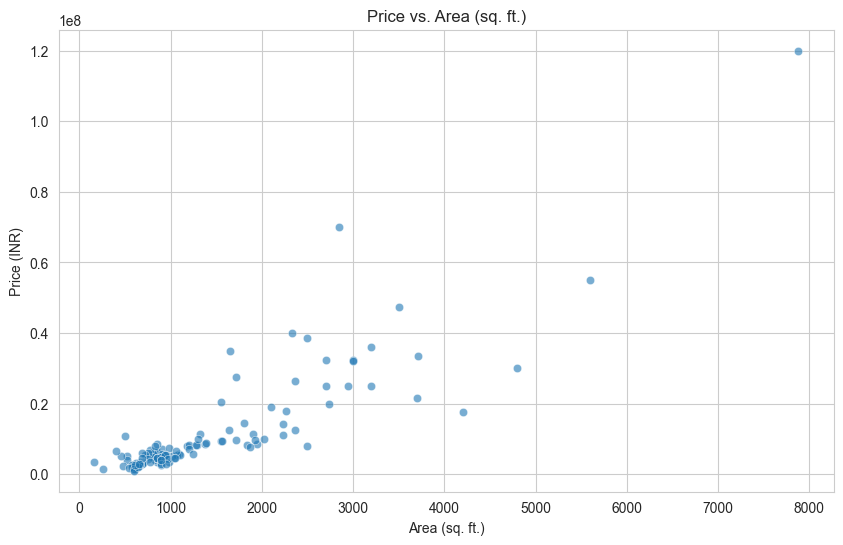

In [18]:




# Set a clean visual style
sns.set_style("whitegrid")

try:
    df = pd.read_csv('processed_data.csv')

    # --- 2. Area vs. Price (The Key Relationship) ---
    print("Area vs. Price")
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='area', y='price', alpha=0.6)
    plt.title('Price vs. Area (sq. ft.)')
    plt.xlabel('Area (sq. ft.)')
    plt.ylabel('Price (INR)')

except FileNotFoundError:
    print("Error: 'processed_data.csv' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

### Model training

In [19]:

df_processed = pd.read_csv('processed_data.csv')

y = df_processed['price']
X = df_processed.drop(['price', 'price_per_sqft'], axis=1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Features Scale 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# linear reg
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"  Linear Regression RMSE: {rmse_lr:,.2f}")
print(f"  Linear Regression R²: {r2_lr:.4f}")

  Linear Regression RMSE: 19,062,459.26
  Linear Regression R²: -1.3917


In [24]:
#random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train) 
y_pred_rf = rf.predict(X_test) 

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"  Random Forest RMSE: {rmse_rf:,.2f}")
print(f"  Random Forest R²: {r2_rf:.4f}")


  Random Forest RMSE: 7,963,457.07
  Random Forest R²: 0.5826



--- Calculating Feature Importance ---
Top 10 Features:
                     feature  importance
0                       area    0.653267
16            locality_score    0.091326
17        builder_experience    0.076010
23            location_Aundh    0.054189
31  location_Deccan Gymkhana    0.034828
25            location_Baner    0.022187
71              facing_north    0.009710
21           amenities_score    0.007518
5            age of property    0.005934
8            24 X 7 Security    0.004865


C:\Users\iiiaamnooob\AppData\Local\Temp\ipykernel_1696\2673066518.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette="rocket")


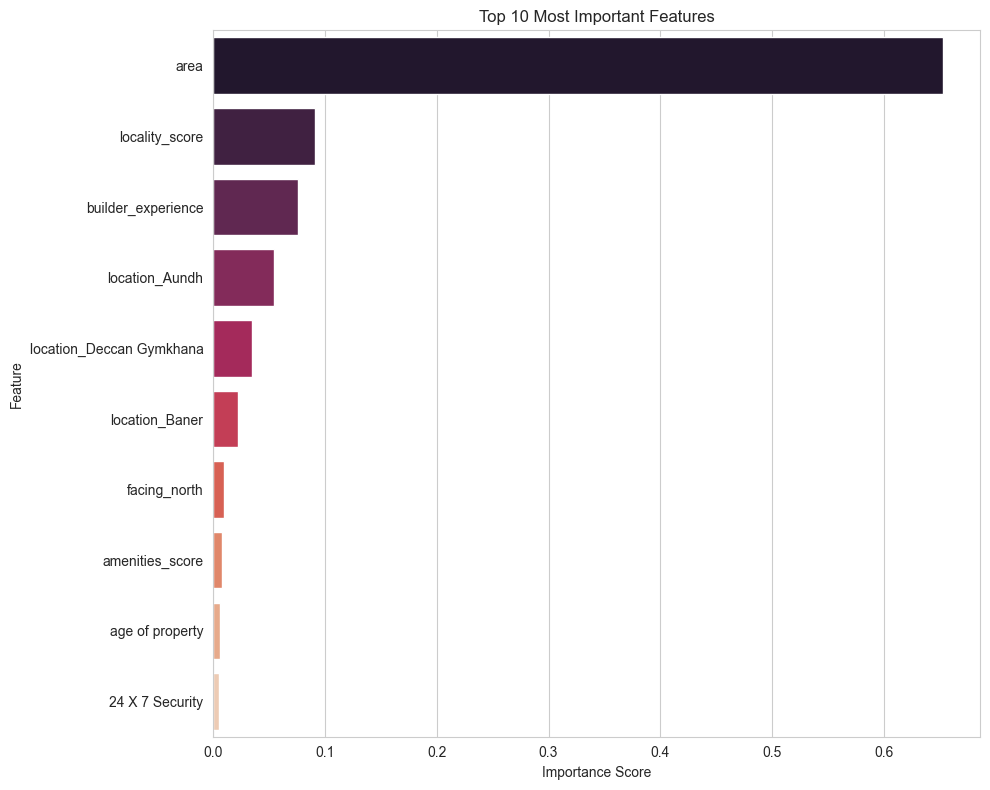

In [ ]:
# obj 9 : imp features
print("\n--- Calculating Feature Importance ---")
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Top 10 Features:")
print(importance_df.head(10).to_string())

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette="rocket")
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()


In [ ]:
print("--- Part 1: Regenerating cleaned data with engineered features ---")

try:
    # --- Load original data ---
    df = pd.read_csv('output_Pune_builderfloor.csv')

    # --- Run Member 1's Cleaning ---
    # 1. Auto-drop High-Null Columns
    missing_percentage = df.isnull().mean()
    cols_to_drop_auto = missing_percentage[missing_percentage > 0.7].index
    
    # 2. Manually Drop Useless Columns
    cols_to_drop_manual = ['description', 'price_currency', 'status']
    
    # Combine and drop
    all_cols_to_drop = cols_to_drop_auto.union(cols_to_drop_manual)
    df_cleaned = df.drop(columns=all_cols_to_drop, errors='ignore')

    # 3. Impute Categorical Nulls
    if 'facing' in df_cleaned.columns:
        df_cleaned['facing'] = df_cleaned['facing'].fillna('Unknown')
    
    # 4. Impute Numerical Nulls
    num_cols_with_na = ['locality_score', 'builder_experience']
    for col in num_cols_with_na:
        if col in df_cleaned.columns:
            median_val = df_cleaned[col].median()
            df_cleaned[col] = df_cleaned[col].fillna(median_val)

    # 5. Impute Amenity Nulls (Fill remaining with 0)
    df_cleaned = df_cleaned.fillna(0)

    # --- Run Member 1's Feature Engineering ---
    # 6. Create `price_per_sqft`
    df_cleaned['price_per_sqft'] = df_cleaned['price'] / df_cleaned['area']
    
    # 7. Create `amenities_score`
    amenity_cols = [
        'Lift(s)', 'Full Power Backup', '24 X 7 Security', "Children's play area",
        'Club House', 'Gymnasium', 'Swimming Pool', 'Sports Facility', 'Jogging Track',
        'Landscaped Gardens', 'Rain Water Harvesting', 'Intercom', 'Car Parking'
    ]
    amenity_cols_present = [col for col in amenity_cols if col in df_cleaned.columns]
    df_cleaned['amenities_score'] = df_cleaned[amenity_cols_present].sum(axis=1)

    # 8. Save this intermediate file
    df_cleaned.to_csv('cleaned_for_heatmap.csv', index=False)
    print("Successfully created 'cleaned_for_heatmap.csv'")

    # --- Part 2: Generate the Heatmap ---
    print("\n--- Part 2: Generating Heatmap for Objective 10 ---")
    
    # 1. Aggregate data by location
    regional_data = df_cleaned.groupby('location').agg(
        average_price=('price', 'mean'),
        average_locality_score=('locality_score', 'mean'),
        average_price_per_sqft=('price_per_sqft', 'mean'),
        listing_count=('area', 'count')
    )
    
    # 2. Filter for top 15 locations
    top_locations = regional_data.sort_values(by='listing_count', ascending=False).head(15)
    
    # 3. Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(top_locations)
    scaled_df = pd.DataFrame(scaled_data, index=top_locations.index, columns=top_locations.columns)
    
    # 4. Plot the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        scaled_df,
        annot=True,          
        fmt=".2f",           
        cmap="viridis",      
        linewidths=0.5
    )
    plt.title('Regional Heatmap: Key Metrics for Top 15 Locations (Scaled)')
    plt.xlabel('Metrics (Scaled)')
    plt.ylabel('Location')
    plt.tight_layout()
    plt.savefig('6_regional_heatmap.png')
    
    print("\n✅ Successfully created '6_regional_heatmap.png'.")
    print("This heatmap shows 'hot zones' based on price, value, desirability, and market size.")

except FileNotFoundError:
    print("CRITICAL ERROR: 'output_Pune_builderfloor.csv' not found.")
except Exception as e:
    print(f"An error occurred: {e}")